In [6]:
%matplotlib inline
import pandas as pd
import numpy as np
import pymc3 as pm
import theano.tensor as tt
import matplotlib.pyplot as plt
import nfldb

# Get historical yards for data for a single team

In [7]:
# year 2009-2015
# week 1-17

# passing yards for week
def team_passing_yds(team, season_year, week, season_type='Regular'):
    db = nfldb.connect()
    q = nfldb.Query(db)

    q.game(season_year=season_year, season_type='Regular', week=week, team=team)
    q.play_player(team=team)
    pps = q.as_aggregate()
    return sum(pp.passing_yds for pp in pps)

# passing yards for year
def team_passing_yds_yearly(team, season_year, season_type='Regular'):
    yds = np.array([])
    for week in range(1, 18):
        yds_week = team_passing_yds(team, season_year, week, season_type)
        if yds_week>0: # hack to avoid bye week
            yds = np.append(yds, yds_week)
    return yds

# passing yard data available
def team_passing_yds_all(team, season_type='Regular'):
    yds = np.array([])
    # this database only has data for 2009 to 2016
    for season_year in range(2009, 2016):
        yds = np.append(yds, team_passing_yds_yearly(team, season_year, season_type))
    return yds

yds = team_passing_yds_all('GB')

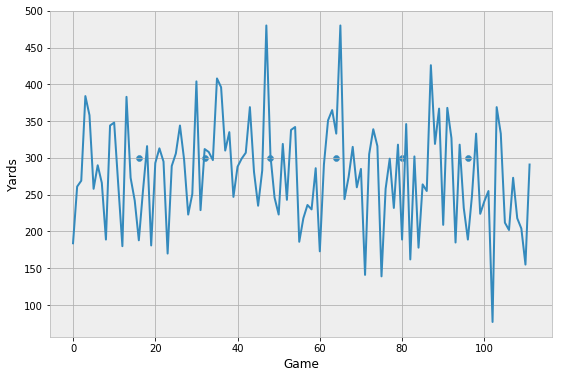

In [8]:
fig = plt.figure(figsize=(9, 6))
plt.xlabel('Game')
plt.ylabel('Yards')
plt.plot(yds)
tick_x = np.arange(16,112,16)
tick_y = 300*np.ones([len(tick_x),1])
plt.scatter(tick_x, tick_y)
plt.show()

In [9]:
model = pm.Model()
from pymc3.distributions.timeseries import GaussianRandomWalk
with model:
    sigma = pm.Exponential('sigma', 1./.02, testval=.1)

    nu = pm.Exponential('nu', 1./10)
    s = GaussianRandomWalk('s', sigma**-2, shape=len(yds))

    r = pm.StudentT('r', nu, lam=pm.math.exp(-2*s), observed=yds)


In [5]:
with model:
    trace = pm.sample(2000)

Auto-assigning NUTS sampler...
Initializing NUTS using advi...
Average ELBO = -1,034.3: 100%|██████████| 200000/200000 [00:19<00:00, 10235.22it/s]
Finished [100%]: Average ELBO = -1,012.7
 16%|█▌        | 320/2000 [00:29<01:27, 19.10it/s]

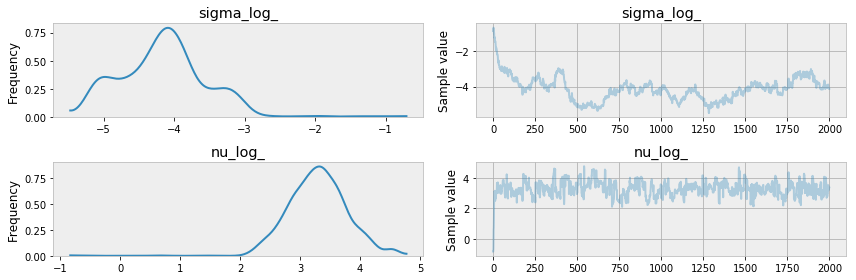

In [155]:
fig = plt.figure(figsize=(12, 6))
pm.traceplot(trace, model.vars[:-1]);

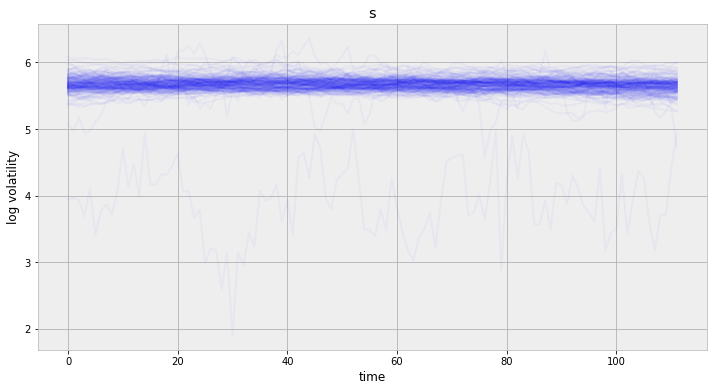

In [156]:
fig = plt.figure(figsize=(12, 6))
plt.title(str(s))
plt.plot(trace[s][::10].T,'b', alpha=.03);
plt.xlabel('time')
plt.ylabel('log volatility')

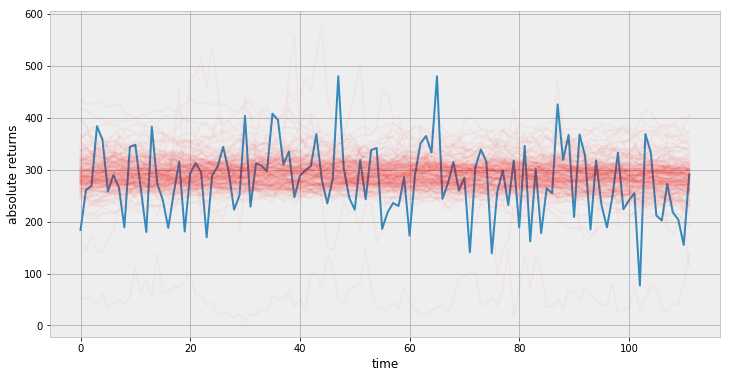

In [160]:
fig = plt.figure(figsize=(12, 6))
plt.plot(np.abs(yds))
plt.plot(np.exp(trace[s][::10].T), 'r', alpha=.03);
sd = np.exp(trace[s].T)
plt.xlabel('time')
plt.ylabel('absolute returns')
    